In [1]:
# =============================================
# Cell 1: 라이브러리 & 데이터 로드
# =============================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

FILE_PATH = r"C:\Users\angel\DS8_SIA\DS8_SIA_Project\project\01_data\satellite\passes_20220804_modern.csv"  # 파일 경로 맞게 수정
df = pd.read_csv(FILE_PATH, encoding='utf-8-sig')

print("=== 기본 정보 ===")
print(f"Shape: {df.shape}")
print(f"\n컬럼: {df.columns.tolist()}")
print(f"\n데이터 타입:\n{df.dtypes}")
print(f"\n처음 5행:")
df.head()

=== 기본 정보 ===
Shape: (1794, 5)

컬럼: ['위성명', 'NORAD_ID', '통과시간(UTC)', '최대앙각(°)', '궤도고도(km)']

데이터 타입:
위성명           object
NORAD_ID       int64
통과시간(UTC)     object
최대앙각(°)      float64
궤도고도(km)     float64
dtype: object

처음 5행:


,위성명,NORAD_ID,통과시간(UTC),최대앙각(°),궤도고도(km)
0,STARLINK-3927,52569,2022-08-04 13:30:00,89.5,543.1
1,TBA - TO BE ASSIGNED,270020,2022-08-04 12:02:00,89.2,938.7
2,TBA - TO BE ASSIGNED,82798,2022-08-04 01:19:00,89.0,865.6
3,MINOTAUR 4 DEB,52975,2022-08-04 02:34:00,88.4,624.4
4,STARLINK-4048,52839,2022-08-04 17:12:00,88.0,465.7


In [2]:
# =============================================
# Cell 2: 기본 통계 & 결측치 확인
# =============================================
print("=== 결측치 ===")
print(df.isnull().sum())

print("\n=== 기술 통계 ===")
df.describe()

=== 결측치 ===
위성명          0
NORAD_ID     0
통과시간(UTC)    0
최대앙각(°)      0
궤도고도(km)     0
dtype: int64

=== 기술 통계 ===


,NORAD_ID,최대앙각(°),궤도고도(km)
count,1794.000000,1794.000000,1794.000000
mean,81773.298774,52.064771,619.095151
std,61392.785085,15.270743,227.668461
min,52561.000000,30.000000,302.400000
25%,52835.250000,38.100000,420.325000
50%,53159.500000,51.400000,543.900000
75%,82524.000000,63.400000,781.575000
max,270285.000000,89.500000,1198.200000


In [3]:
# =============================================
# Cell 3: 시간 파싱 & 2022-08-04 필터링
# =============================================
df['통과시간(UTC)'] = pd.to_datetime(df['통과시간(UTC)'])
df['날짜'] = df['통과시간(UTC)'].dt.date
df['시간(hour)'] = df['통과시간(UTC)'].dt.hour

# 이벤트 날짜 필터
EVENT_DATE = '2022-08-04'
df_event = df[df['통과시간(UTC)'].dt.strftime('%Y-%m-%d') == EVENT_DATE]

print(f"=== {EVENT_DATE} 기준 ===")
print(f"총 pass 수: {len(df_event)}개")
print(f"고유 위성 수: {df_event['NORAD_ID'].nunique()}개")
print(f"\n시간대별 pass 수:")
print(df_event['시간(hour)'].value_counts().sort_index())

=== 2022-08-04 기준 ===
총 pass 수: 1794개
고유 위성 수: 916개

시간대별 pass 수:
시간(hour)
0      77
1      69
2      55
3     118
4      40
5     106
6      55
7      79
8      67
9     123
10     51
11     50
12     92
13     57
14     56
15     67
16     73
17    173
18     51
19     35
20     34
21    117
22     73
23     76
Name: count, dtype: int64


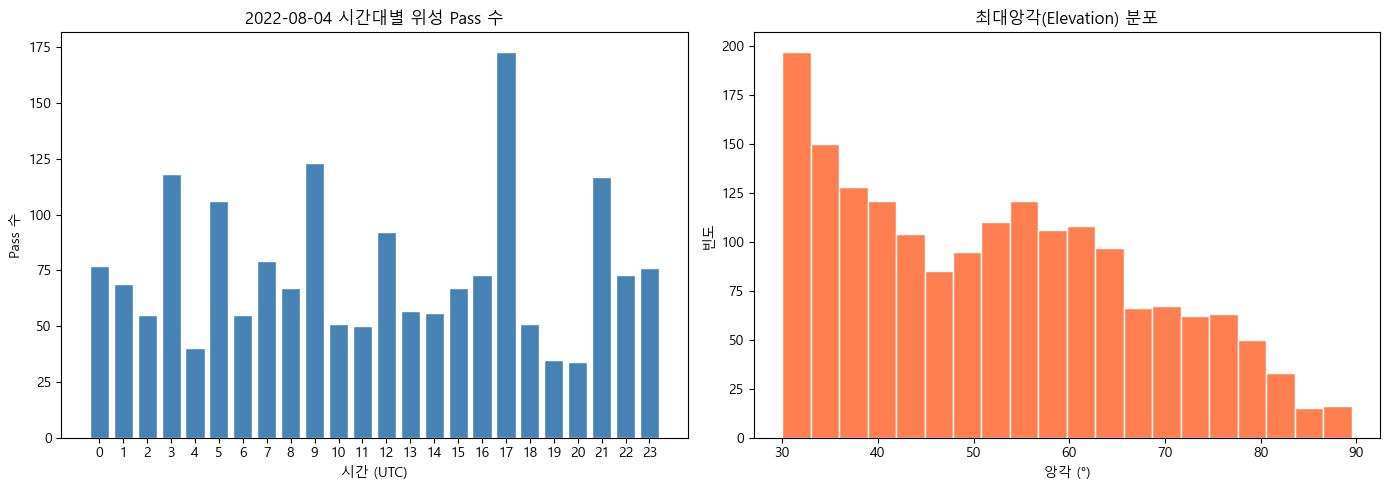

In [4]:
# =============================================
# Cell 4: 시간대별 pass 분포 시각화
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 시간대별 pass 수
hourly = df_event['시간(hour)'].value_counts().sort_index()
axes[0].bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
axes[0].set_title(f'{EVENT_DATE} 시간대별 위성 Pass 수')
axes[0].set_xlabel('시간 (UTC)')
axes[0].set_ylabel('Pass 수')
axes[0].set_xticks(range(0, 24))

# 최대앙각 분포
axes[1].hist(df_event['최대앙각(°)'], bins=20, color='coral', edgecolor='white')
axes[1].set_title('최대앙각(Elevation) 분포')
axes[1].set_xlabel('앙각 (°)')
axes[1].set_ylabel('빈도')

plt.tight_layout()
plt.show()

#### 왼쪽 파란 그래프: 시간대별 위성 pass 수
- 17시(UTC)에 173개로 최다 → 이 시간대에 위성이 가장 밀집 통과
- 전반적으로 하루 종일 고르게 분포 (최소 33개~최대 173개)
- Phase 4 설계 시사점: 특정 시간대에 촬영 위성을 집중 배치할 필요 없음. 어느 시간대든 관측 가능한 위성이 충분히 있음

#### 오른쪽 주황 그래프: 최대 양각 분포
- 위성들이 얼마나 정수리 위를 지나가는지..
- 양각 (Elevation): 지상에서 위성을 올려볼 때의 각도. 90도면 바로 머리 위.
- 양각이 높을수록 위성이 더 정면으로 지나감 -> 촬영 품질 올라감 + 관측 면적 작아짐
- 양각이 낮을 수록 비스듬히 지나감 -> 촬영 면적 넓어짐 + 왜곡/노이즈 많아짐

=== 궤도 종류별 분포 ===
궤도종류
LEO (<2000km)    1794
Name: count, dtype: int64


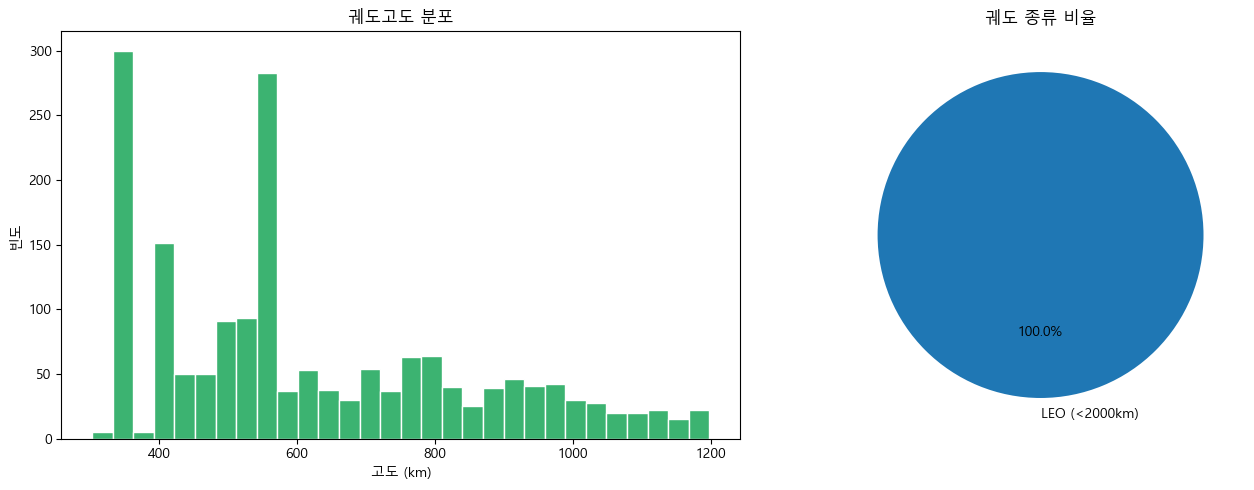

In [5]:
# =============================================
# Cell 5: 궤도고도 분포 & 위성군 분류
# =============================================
# 고도 구간 분류 (LEO / MEO / GEO 기준)
def classify_orbit(alt):
    if alt < 2000:
        return 'LEO (<2000km)'
    elif alt < 35786:
        return 'MEO (2000~35786km)'
    else:
        return 'GEO (≥35786km)'

df_event['궤도종류'] = df_event['궤도고도(km)'].apply(classify_orbit)

print("=== 궤도 종류별 분포 ===")
print(df_event['궤도종류'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 고도 히스토그램
axes[0].hist(df_event['궤도고도(km)'], bins=30, color='mediumseagreen', edgecolor='white')
axes[0].set_title('궤도고도 분포')
axes[0].set_xlabel('고도 (km)')
axes[0].set_ylabel('빈도')

# 궤도 종류 파이차트
orbit_counts = df_event['궤도종류'].value_counts()
axes[1].pie(orbit_counts.values, labels=orbit_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('궤도 종류 비율')

plt.tight_layout()
plt.show()

- 궤도고도: 위성이 지표면으로붙 얼마나 높이 있는지...
- 높을수록 -> 한 번에 보이는 면적 넓음 + 해상도 낮음
- 낮을수록 -> 좁은 범위 + 해상도 높음.
---

- 300~400km 구간 피크 (약 300개): Starlink 등 초저궤도 위성 군집
- 500~600km 구간 피크 (약 280개): Planet Labs, Starlink 등 주요 상업 위성 군집
- 100% LEO(저궤도, <2000km): 이 데이터의 모든 위성이 저궤도 위성
- Phase 4 설계 시사점: LEO 위성은 지나가는 속도가 빠름 (약 7~8km/s). 촬영 윈도우가 수 분밖에 안 됨 → 정확한 통과 시간 계산이 중요

In [6]:
# =============================================
# Cell 6: 앙각 기준 관측 가능성 필터링
# =============================================
# 앙각이 높을수록 직하점(Nadir)에 가까움 → 관측 품질 ↑
# 일반적으로 30° 이상이면 충분한 관측 가능

thresholds = [0, 10, 20, 30, 45, 60]
print("=== 앙각 기준별 통과 위성 수 ===")
for t in thresholds:
    count = len(df_event[df_event['최대앙각(°)'] >= t])
    print(f"  앙각 ≥ {t:2d}°: {count}개")

# 앙각 30° 이상 위성만 추출 (고품질 후보)
df_high_elev = df_event[df_event['최대앙각(°)'] >= 30].copy()
print(f"\n앙각 30° 이상 고품질 후보 위성: {len(df_high_elev)}개")
print(df_high_elev[['위성명', 'NORAD_ID', '통과시간(UTC)', '최대앙각(°)', '궤도고도(km)']].sort_values('최대앙각(°)', ascending=False).head(10))

=== 앙각 기준별 통과 위성 수 ===
  앙각 ≥  0°: 1794개
  앙각 ≥ 10°: 1794개
  앙각 ≥ 20°: 1794개
  앙각 ≥ 30°: 1794개
  앙각 ≥ 45°: 1090개
  앙각 ≥ 60°: 568개

앙각 30° 이상 고품질 후보 위성: 1794개
                    위성명  NORAD_ID           통과시간(UTC)  최대앙각(°)  궤도고도(km)
0         STARLINK-3927     52569 2022-08-04 13:30:00     89.5     543.1
1  TBA - TO BE ASSIGNED    270020 2022-08-04 12:02:00     89.2     938.7
2  TBA - TO BE ASSIGNED     82798 2022-08-04 01:19:00     89.0     865.6
3        MINOTAUR 4 DEB     52975 2022-08-04 02:34:00     88.4     624.4
4         STARLINK-4048     52839 2022-08-04 17:12:00     88.0     465.7
5  TBA - TO BE ASSIGNED     81366 2022-08-04 01:30:00     87.6     961.1
6  TBA - TO BE ASSIGNED     82526 2022-08-04 12:34:00     87.5     889.7
7  TBA - TO BE ASSIGNED     89494 2022-08-04 12:08:00     87.4     927.5
8  TBA - TO BE ASSIGNED     87883 2022-08-04 02:38:00     87.4    1060.1
9  TBA - TO BE ASSIGNED     82303 2022-08-04 01:45:00     87.3    1097.4


- 양각 기준에 따른 후보 위성 
    - 양각 >= 60 : 568개 -> 전체의 32%정도, 고품질 후보 위성임.

- ROi 반경을 양각 60도 이상 기준으로 잡으면 568개로 좁혀짐. 꽤 많기 때문에 추가로 EO/SAR 센서 타입, Swath width 등으로 더 필터링해도 됨.

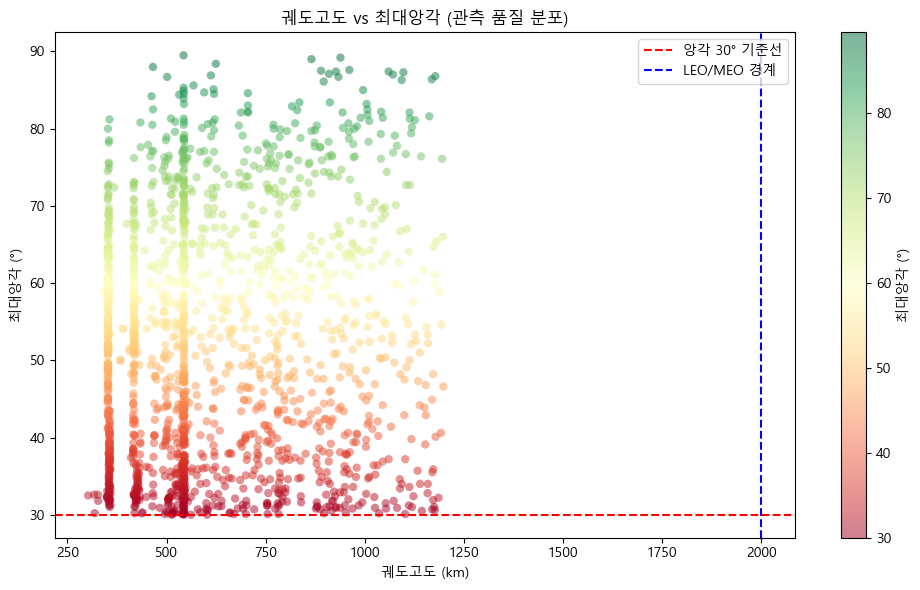

In [7]:
# =============================================
# Cell 7: 앙각 vs 고도 산점도 (관측 품질 종합)
# =============================================
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_event['궤도고도(km)'],
    df_event['최대앙각(°)'],
    alpha=0.5, c=df_event['최대앙각(°)'], cmap='RdYlGn', edgecolors='none'
)
ax.axhline(y=30, color='red', linestyle='--', linewidth=1.5, label='앙각 30° 기준선')
ax.axvline(x=2000, color='blue', linestyle='--', linewidth=1.5, label='LEO/MEO 경계')
ax.set_xlabel('궤도고도 (km)')
ax.set_ylabel('최대앙각 (°)')
ax.set_title('궤도고도 vs 최대앙각 (관측 품질 분포)')
ax.legend()
plt.colorbar(scatter, ax=ax, label='최대앙각 (°)')
plt.tight_layout()
plt.show()

- x축: 궤도고도 (낮을수록 왼쪽), y축: 최대앙각 (높을수록 위)
- 초록색(좋음): 앙각 높음 → 양질의 관측 가능
- 빨간색(나쁨): 앙각 낮음 → 비스듬한 관측

- 고도가 높아질수록(오른쪽으로 갈수록) 앙각이 고르게 분산 → 높은 궤도 위성은 넓은 범위를 커버하므로 다양한 앙각으로 관측 가능
- 파란 점선(LEO/MEO 경계, 2000km) 오른쪽엔 데이터가 없음 → 전부 LEO 확인

In [8]:
# =============================================
# Cell 8: 상위 위성 리스트 출력 (종합 요약)
# =============================================
print("=== 종합 요약 ===")
print(f"전체 Pass 수      : {len(df_event)}개")
print(f"고유 위성 수       : {df_event['NORAD_ID'].nunique()}개")
print(f"평균 앙각          : {df_event['최대앙각(°)'].mean():.1f}°")
print(f"평균 궤도고도       : {df_event['궤도고도(km)'].mean():.1f} km")
print(f"\nLEO 위성 수       : {len(df_event[df_event['궤도종류']=='LEO (<2000km)'])}개")
print(f"앙각 30° 이상     : {len(df_event[df_event['최대앙각(°)'] >= 30])}개")
print(f"앙각 60° 이상     : {len(df_event[df_event['최대앙각(°)'] >= 60])}개")

print("\n=== 앙각 상위 10개 위성 ===")
top10 = df_event.nlargest(10, '최대앙각(°)')[['위성명','NORAD_ID','통과시간(UTC)','최대앙각(°)','궤도고도(km)']]
print(top10.to_string(index=False))

=== 종합 요약 ===
전체 Pass 수      : 1794개
고유 위성 수       : 916개
평균 앙각          : 52.1°
평균 궤도고도       : 619.1 km

LEO 위성 수       : 1794개
앙각 30° 이상     : 1794개
앙각 60° 이상     : 568개

=== 앙각 상위 10개 위성 ===
                 위성명  NORAD_ID           통과시간(UTC)  최대앙각(°)  궤도고도(km)
       STARLINK-3927     52569 2022-08-04 13:30:00     89.5     543.1
TBA - TO BE ASSIGNED    270020 2022-08-04 12:02:00     89.2     938.7
TBA - TO BE ASSIGNED     82798 2022-08-04 01:19:00     89.0     865.6
      MINOTAUR 4 DEB     52975 2022-08-04 02:34:00     88.4     624.4
       STARLINK-4048     52839 2022-08-04 17:12:00     88.0     465.7
TBA - TO BE ASSIGNED     81366 2022-08-04 01:30:00     87.6     961.1
TBA - TO BE ASSIGNED     82526 2022-08-04 12:34:00     87.5     889.7
TBA - TO BE ASSIGNED     89494 2022-08-04 12:08:00     87.4     927.5
TBA - TO BE ASSIGNED     87883 2022-08-04 02:38:00     87.4    1060.1
TBA - TO BE ASSIGNED     82303 2022-08-04 01:45:00     87.3    1097.4


### Phase 4
- pass 수: 후보위성이 충분히 많아서, 추가 필터 기준이 필요하다!!
- 시간 분포: 고름. 특정 시간 제한이 없어도 될듯.
- 앙각: 60도 이상으로 해도 위성 후보가 많아서, 기준이 필요할 듯.
    - 넓은 범위를 볼 것인지 -> 군사 활동의 흐름?을 보겠다.
    - 좁은 범위를 고품질로 볼 것인지 

- 궤도고도: 일단 이 데이터는 LEO만 뽑은 거이기 때문에,
    - LEO만 사용한다면, 통과 시간이 짧기 때문에, 좌표 정밀 스케줄링이 필요하다.

- 센서 정보: 해당 데이터엔 없음. 추후에 확인 필요.

In [9]:
# =============================================
# Cell 9: 지상 거리 계산 (ROI 반경 결정)
# =============================================
import numpy as np

R_EARTH = 6371  # 지구 반지름 (km)

def calc_ground_distance(elevation_deg, altitude_km):
    """
    최대앙각 + 궤도고도 → 위성 직하점(Sub-satellite point)까지의 지상 거리 계산
    
    원리:
    - 위성이 최대앙각일 때 = 위성이 관측 지점에 가장 가까운 순간
    - 이때 지상 기준으로 이벤트 좌표에서 위성 직하점까지의 거리를 계산
    - 앙각 90° = 위성이 바로 머리 위 = 지상 거리 0km
    - 앙각 30° = 비스듬히 지남 = 지상 거리 수백 km
    """
    el_rad = np.radians(elevation_deg)
    
    # 위성에서의 nadir각 계산
    nadir_angle = np.arcsin(R_EARTH * np.cos(el_rad) / (R_EARTH + altitude_km))
    
    # 지구 중심각 계산
    earth_central_angle = np.radians(90) - el_rad - nadir_angle
    
    # 지상 거리 = 지구반지름 × 중심각(라디안)
    ground_distance = R_EARTH * earth_central_angle
    
    return round(ground_distance, 1)

# 데이터 전체에 지상 거리 계산
df_event['지상거리(km)'] = df_event.apply(
    lambda row: calc_ground_distance(row['최대앙각(°)'], row['궤도고도(km)']), axis=1
)

print("=== 지상 거리 기술 통계 ===")
print(df_event['지상거리(km)'].describe().round(1))

print("\n=== ROI 반경 설정 기준 (앙각 구간별 지상 거리) ===")
bins = [30, 45, 60, 75, 90]
labels = ['30~45°', '45~60°', '60~75°', '75~90°']
df_event['앙각구간'] = pd.cut(df_event['최대앙각(°)'], bins=bins, labels=labels)

roi_summary = df_event.groupby('앙각구간', observed=True)['지상거리(km)'].agg(['mean','median','max','count']).round(1)
roi_summary.columns = ['평균거리(km)', '중앙값(km)', '최대거리(km)', '위성수']
print(roi_summary)

=== 지상 거리 기술 통계 ===
count    1794.0
mean      454.9
std       278.0
min         4.4
25%       233.2
50%       404.6
75%       628.2
max      1423.5
Name: 지상거리(km), dtype: float64

=== ROI 반경 설정 기준 (앙각 구간별 지상 거리) ===
        평균거리(km)  중앙값(km)  최대거리(km)  위성수
앙각구간                                    
30~45°     701.4    668.7    1423.5  701
45~60°     396.5    355.8     897.1  522
60~75°     238.3    215.8     536.4  398
75~90°     114.2    114.8     247.9  169


- ROI를 생성한다면, 얼마나 크게 잡아야 하나..?
- 지상 거리: 위성이 최대 양각일때, 이벤트 좌표에서 위성의 직하점 까지의 거리
- 90도면 직하점이 이벤트 좌표와 일치 = 지상거리는 0km
- 60도 이상부터가 크기도 너무 작지도 않고 괜찮을듯. 위성 수도 나름 많아서.

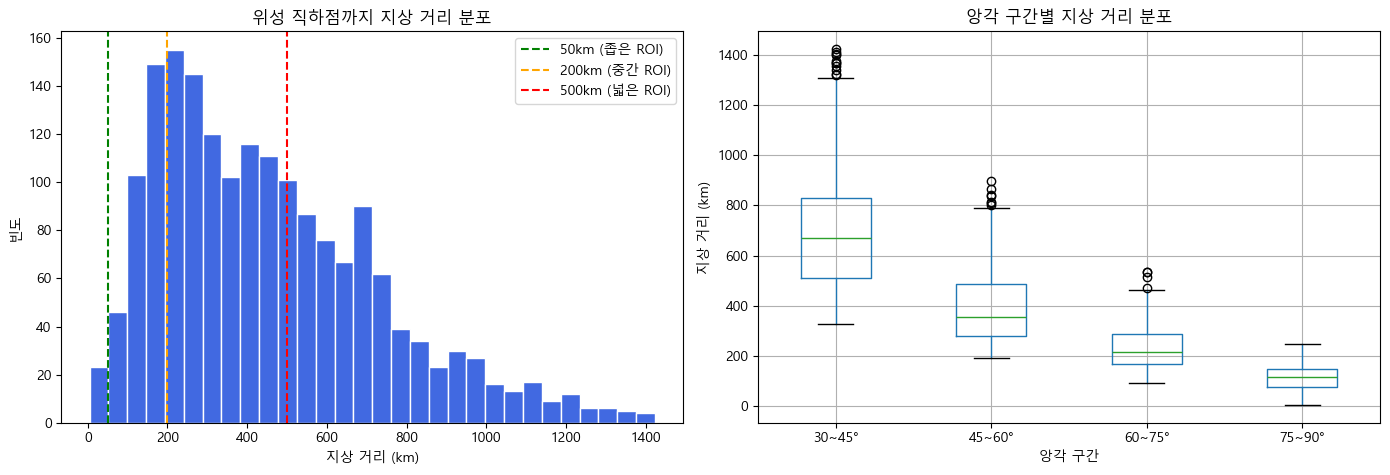


💡 ROI 반경 가이드:
  앙각 60° 이상 위성만 쓸 경우 → ROI 반경 약 183km 이내
  앙각 45° 이상 위성까지 포함  → ROI 반경 약 262km 이내
  전체 위성 포함               → ROI 반경 약 405km 이내


In [10]:
# =============================================
# Cell 10: 지상 거리 분포 시각화
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 지상 거리 히스토그램
axes[0].hist(df_event['지상거리(km)'], bins=30, color='royalblue', edgecolor='white')
axes[0].axvline(x=50,  color='green', linestyle='--', linewidth=1.5, label='50km (좁은 ROI)')
axes[0].axvline(x=200, color='orange', linestyle='--', linewidth=1.5, label='200km (중간 ROI)')
axes[0].axvline(x=500, color='red', linestyle='--', linewidth=1.5, label='500km (넓은 ROI)')
axes[0].set_title('위성 직하점까지 지상 거리 분포')
axes[0].set_xlabel('지상 거리 (km)')
axes[0].set_ylabel('빈도')
axes[0].legend()

# 앙각 구간별 지상 거리 박스플롯
df_event.boxplot(column='지상거리(km)', by='앙각구간', ax=axes[1])
axes[1].set_title('앙각 구간별 지상 거리 분포')
axes[1].set_xlabel('앙각 구간')
axes[1].set_ylabel('지상 거리 (km)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\n💡 ROI 반경 가이드:")
print(f"  앙각 60° 이상 위성만 쓸 경우 → ROI 반경 약 {df_event[df_event['최대앙각(°)'] >= 60]['지상거리(km)'].median():.0f}km 이내")
print(f"  앙각 45° 이상 위성까지 포함  → ROI 반경 약 {df_event[df_event['최대앙각(°)'] >= 45]['지상거리(km)'].median():.0f}km 이내")
print(f"  전체 위성 포함               → ROI 반경 약 {df_event['지상거리(km)'].median():.0f}km 이내")

#### 왼쪽 그래프: 지상 거리 히스토그램
- 분포가 100~500km 구간에 집중 (가장 많은 위성이 이 범위로 지나감)
- 50km(초록선) 이내: 극소수 → 바로 위를 지나는 위성은 드묾
- 200km(주황선) 이내: 꽤 적은 수 → 고품질 위성만 포함
- 500km(빨간선) 이내: 절반 이상 커버
- → ROI를 500km로 잡으면 위성이 너무 많고, 50km면 너무 적음. 200km 내외가 현실적

#### 오른쪽 그래프: 양각 구간별 boxplot
- 30~45° 박스: 위아래로 넓게 퍼져있음 → 지상 거리가 들쭉날쭉, 예측 어려움
- 75~90° 박스: 좁고 낮게 모여있음 → 안정적으로 이벤트 좌표 바로 위를 지남
- 앙각이 높아질수록 박스가 작아지고 아래로 내려옴 → 일관성 있는 고품질 관측

In [11]:
# =============================================
# Cell 11: 이벤트 시간 전후 필터링
# =============================================
# 2022-08-04 대만 미사일 발사 시각 (UTC 13:56 기준)
# 전후 ±N시간 범위로 "촬영 가능 위성" 좁히기

EVENT_TIME = pd.Timestamp('2022-08-04 13:56:00')

windows = [1, 2, 3, 6]  # ±1h, ±2h, ±3h, ±6h

print(f"=== 이벤트 시각: {EVENT_TIME} (UTC) ===\n")
print("시간 윈도우별 통과 위성 수:")

for w in windows:
    start = EVENT_TIME - pd.Timedelta(hours=w)
    end   = EVENT_TIME + pd.Timedelta(hours=w)
    count = len(df_event[
        (df_event['통과시간(UTC)'] >= start) &
        (df_event['통과시간(UTC)'] <= end)
    ])
    print(f"  ±{w}시간 ({start.strftime('%H:%M')}~{end.strftime('%H:%M')} UTC): {count}개")

# ±3시간 기준으로 후보 추출 (조정 가능)
WINDOW_HOURS = 3
df_near_event = df_event[
    (df_event['통과시간(UTC)'] >= EVENT_TIME - pd.Timedelta(hours=WINDOW_HOURS)) &
    (df_event['통과시간(UTC)'] <= EVENT_TIME + pd.Timedelta(hours=WINDOW_HOURS))
].copy()

print(f"\n=== ±{WINDOW_HOURS}시간 내 후보 위성 상세 ===")
print(f"총 {len(df_near_event)}개 / 고유 위성 {df_near_event['NORAD_ID'].nunique()}개")
print(df_near_event.sort_values('통과시간(UTC)')[
    ['위성명','NORAD_ID','통과시간(UTC)','최대앙각(°)','궤도고도(km)','지상거리(km)']
].to_string(index=False))

=== 이벤트 시각: 2022-08-04 13:56:00 (UTC) ===

시간 윈도우별 통과 위성 수:
  ±1시간 (12:56~14:56 UTC): 119개
  ±2시간 (11:56~15:56 UTC): 276개
  ±3시간 (10:56~16:56 UTC): 392개
  ±6시간 (07:56~19:56 UTC): 895개

=== ±3시간 내 후보 위성 상세 ===
총 392개 / 고유 위성 364개
                    위성명  NORAD_ID           통과시간(UTC)  최대앙각(°)  궤도고도(km)  지상거리(km)
   TBA - TO BE ASSIGNED     87725 2022-08-04 10:58:00     45.9     745.3     618.5
        GLOBALSTAR FM15     52888 2022-08-04 11:04:00     57.5    1121.8     591.1
               OBJECT E     53320 2022-08-04 11:04:00     46.1     500.8     433.0
               OBJECT D     53319 2022-08-04 11:05:00     44.4     501.7     458.5
   TBA - TO BE ASSIGNED     89184 2022-08-04 11:06:00     74.9     773.5     185.4
   TBA - TO BE ASSIGNED    270175 2022-08-04 11:06:00     35.5    1170.5    1228.4
               OBJECT C     53318 2022-08-04 11:06:00     44.1     501.9     463.1
               OBJECT B     53317 2022-08-04 11:07:00     44.1     502.3     463.5
   TBA - TO BE ASSIGNED 

- 이벤트 당시, 실제로 촬영 가능했던 위성 찾기..

=== Constellation 분포 ===
Constellation
Starlink (SpaceX)     733
미분류(TBA)              706
기타                    211
우주 파편(Debris)         131
로켓 잔해(Rocket Body)     12
Planet Labs             1
Name: count, dtype: int64


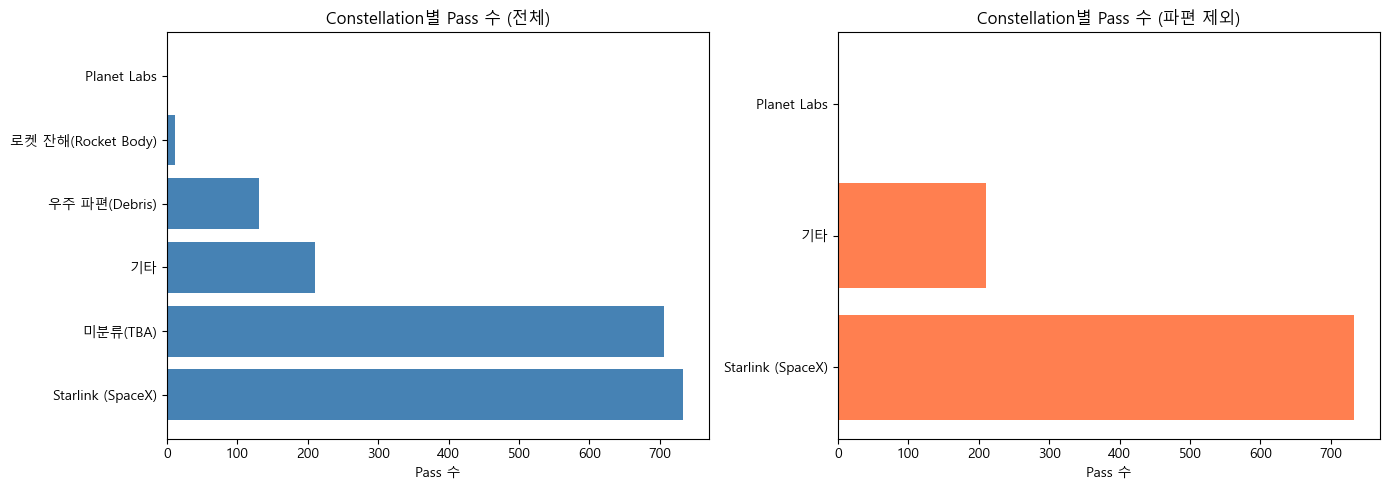

In [12]:
# =============================================
# Cell 12: Constellation(위성군) 분류
# =============================================
def classify_constellation(name):
    name = str(name).upper()
    if 'STARLINK'  in name: return 'Starlink (SpaceX)'
    elif 'ONEWEB'  in name: return 'OneWeb'
    elif 'PLANET'  in name: return 'Planet Labs'
    elif 'IRIDIUM' in name: return 'Iridium'
    elif 'DOVE'    in name: return 'Planet (Dove)'
    elif 'FLOCK'   in name: return 'Planet (Flock)'
    elif 'SKYSAT'  in name: return 'SkySat'
    elif 'TBA'     in name: return '미분류(TBA)'
    elif 'DEB'     in name: return '우주 파편(Debris)'
    elif 'R/B'     in name: return '로켓 잔해(Rocket Body)'
    else:                   return '기타'

df_event['Constellation'] = df_event['위성명'].apply(classify_constellation)

print("=== Constellation 분포 ===")
print(df_event['Constellation'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 전체 분포
const_counts = df_event['Constellation'].value_counts()
axes[0].barh(const_counts.index, const_counts.values, color='steelblue')
axes[0].set_title('Constellation별 Pass 수 (전체)')
axes[0].set_xlabel('Pass 수')

# 미분류/파편 제외한 실제 위성만
df_real = df_event[~df_event['Constellation'].isin(['미분류(TBA)', '우주 파편(Debris)', '로켓 잔해(Rocket Body)'])]
real_counts = df_real['Constellation'].value_counts()
axes[1].barh(real_counts.index, real_counts.values, color='coral')
axes[1].set_title('Constellation별 Pass 수 (파편 제외)')
axes[1].set_xlabel('Pass 수')

plt.tight_layout()
plt.show()

#### 어떤 회사/군집의 위성이 이 지역을 커버하는가?
- 위성 선정 기준 수립을 위해..
- Starlink (SpaceX): 733개. 가장 많음. -> 통신 위성이라 EO(광학 촬영)이 불가능...
- TBA(미분류) : 706개 -> 근데 정체 불명 -> 향후 분류가 필요할듯.
- 기타: 211개 -> 소규모 위성들..
- 우주 파편(Debris), 로켓 잔해: 촬영 불가!! -> 필터링을 빼야 할듯
- Planet Labs: 1개 -> EO 상업위성 -> 수가 많았다면...관심있게 봐도 괜찮았을 텐데.

- 정리해보면, 실제 관측 가능한 위성이 많지가 않다..!!

=== 재방문 횟수 분포 ===
pass횟수
1    226
2    533
3    131
4     22
5      3
6      1
Name: count, dtype: int64

하루 1회만 통과: 226개 위성
하루 2회 이상  : 690개 위성
하루 3회 이상  : 157개 위성

=== 재방문 가장 많은 위성 Top 10 ===
                 위성명  NORAD_ID  pass횟수  평균재방문간격(h)
TBA - TO BE ASSIGNED    270278       6        4.42
            OBJECT A     53316       5        2.08
TBA - TO BE ASSIGNED    270066       5        5.30
TBA - TO BE ASSIGNED    270119       5        5.79
       STARLINK-3979     52608       4        7.41
       STARLINK-3975     52620       4        7.96
       STARLINK-3832     52646       4        4.47
       STARLINK-4078     52689       4        7.96
       STARLINK-3945     52691       4        2.82
       STARLINK-3946     52693       4        7.41


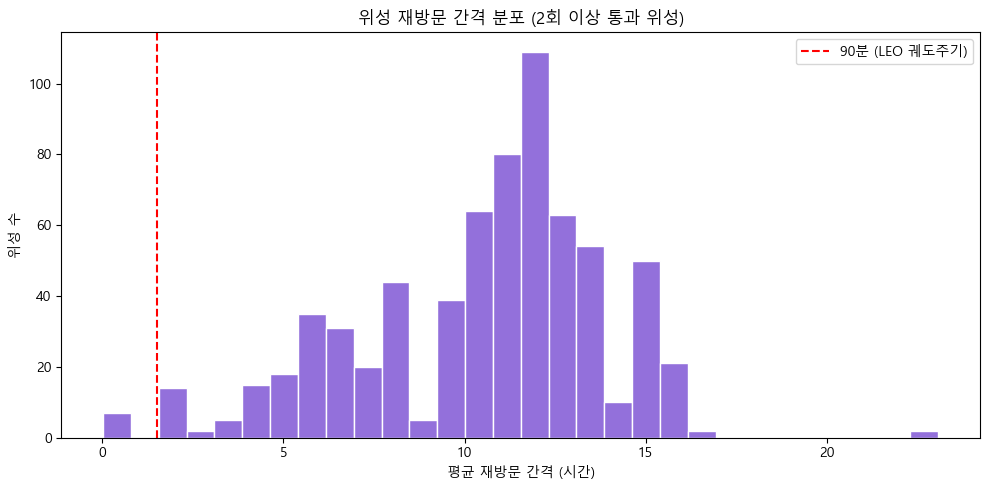

In [13]:
# =============================================
# Cell 13: 재방문 주기 분석
# =============================================
# 같은 위성이 하루에 몇 번, 몇 시간 간격으로 재방문하는가

revisit = df_event.groupby('NORAD_ID').agg(
    위성명=('위성명', 'first'),
    pass횟수=('통과시간(UTC)', 'count'),
    통과시간목록=('통과시간(UTC)', list)
).reset_index()

# 재방문 간격 계산 (2회 이상 통과한 위성만)
def calc_revisit_interval(times):
    if len(times) < 2:
        return None
    times_sorted = sorted(times)
    intervals = [(times_sorted[i+1] - times_sorted[i]).seconds / 3600
                 for i in range(len(times_sorted)-1)]
    return round(np.mean(intervals), 2)

revisit['평균재방문간격(h)'] = revisit['통과시간목록'].apply(calc_revisit_interval)

print("=== 재방문 횟수 분포 ===")
print(revisit['pass횟수'].value_counts().sort_index())

print(f"\n하루 1회만 통과: {len(revisit[revisit['pass횟수']==1])}개 위성")
print(f"하루 2회 이상  : {len(revisit[revisit['pass횟수']>=2])}개 위성")
print(f"하루 3회 이상  : {len(revisit[revisit['pass횟수']>=3])}개 위성")

print("\n=== 재방문 가장 많은 위성 Top 10 ===")
print(revisit.nlargest(10, 'pass횟수')[
    ['위성명', 'NORAD_ID', 'pass횟수', '평균재방문간격(h)']
].to_string(index=False))

# 재방문 간격 분포
fig, ax = plt.subplots(figsize=(10, 5))
revisit_multi = revisit[revisit['평균재방문간격(h)'].notna()]
ax.hist(revisit_multi['평균재방문간격(h)'], bins=30, color='mediumpurple', edgecolor='white')
ax.set_title('위성 재방문 간격 분포 (2회 이상 통과 위성)')
ax.set_xlabel('평균 재방문 간격 (시간)')
ax.set_ylabel('위성 수')
ax.axvline(x=1.5, color='red', linestyle='--', label='90분 (LEO 궤도주기)')
ax.legend()
plt.tight_layout()
plt.show()

#### 재방문 주기 분석
- 같은 위성이 얼마나 자주 돌아오는지... -> 이후 촬영 스케쥴링 설계에 필요하다.
- 재방문 주기: 같은 위성이 같은 지점 위를 다시 지나오는데 걸리는 시간
- LEO 위성은 약 90분에 지구 한바퀴 -> 하루 최대 16번 궤도
- 하지만, 지구가 자전해서 -> 같은 지점 위를 지나는 건 평균 하루 1~3번이 보통..

In [14]:
# =============================================
# Cell 14: 종합 후보 위성 필터링 (Phase 4 설계용)
# =============================================
# 조건: ±3시간 이내 + 앙각 60° 이상 + 파편/TBA 제외

df_candidate = df_event[
    (df_event['통과시간(UTC)'] >= EVENT_TIME - pd.Timedelta(hours=3)) &
    (df_event['통과시간(UTC)'] <= EVENT_TIME + pd.Timedelta(hours=3)) &
    (df_event['최대앙각(°)'] >= 60) &
    (~df_event['Constellation'].isin(['미분류(TBA)', '우주 파편(Debris)', '로켓 잔해(Rocket Body)']))
].copy()

print("=" * 55)
print("   Phase 4 위성 매칭 후보 (최종 필터링 결과)")
print("=" * 55)
print(f"  조건: 이벤트 ±3h / 앙각 ≥60° / 식별 가능 위성")
print(f"  후보 위성 수: {len(df_candidate)}개")
print("=" * 55)

print(df_candidate.sort_values('최대앙각(°)', ascending=False)[
    ['위성명','NORAD_ID','통과시간(UTC)','최대앙각(°)','궤도고도(km)','지상거리(km)','Constellation']
].to_string(index=False))

print(f"\n💡 이 위성들의 지상거리 중앙값 → ROI 반경 권장: {df_candidate['지상거리(km)'].median():.0f}km")

   Phase 4 위성 매칭 후보 (최종 필터링 결과)
  조건: 이벤트 ±3h / 앙각 ≥60° / 식별 가능 위성
  후보 위성 수: 42개
          위성명  NORAD_ID           통과시간(UTC)  최대앙각(°)  궤도고도(km)  지상거리(km)     Constellation
STARLINK-3927     52569 2022-08-04 13:30:00     89.5     543.1       4.4 Starlink (SpaceX)
STARLINK-4074     52678 2022-08-04 15:06:00     85.3     543.1      41.1 Starlink (SpaceX)
STARLINK-3946     52693 2022-08-04 15:10:00     84.9     543.0      44.6 Starlink (SpaceX)
STARLINK-4075     52670 2022-08-04 15:47:00     83.9     542.9      53.4 Starlink (SpaceX)
STARLINK-4033     52702 2022-08-04 15:24:00     78.8     543.3      99.0 Starlink (SpaceX)
STARLINK-4067     52668 2022-08-04 15:51:00     78.7     542.9      99.8 Starlink (SpaceX)
STARLINK-4064     52665 2022-08-04 15:46:00     77.3     542.7     112.5 Starlink (SpaceX)
   SLINGSHOT1     52947 2022-08-04 16:47:00     76.3     494.6     111.7                기타
STARLINK-4018     52697 2022-08-04 15:29:00     76.1     543.1     123.6 Starlink (SpaceX)
STARLINK